**Q2**: How well does each constructor perform on average at specific circuits: Do
specific constructors perform better or worse at certain circuits. We can determine this
by comparing the average lap times between constructors.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [28]:
df = pd.read_csv('/content/drive/MyDrive/UBCO/COSC301/Lab9/avg_laptime.csv')
print(df.head())

df_eachCirc = pd.read_csv('/content/drive/MyDrive/UBCO/COSC301/Lab9/avg_laptime_per_circuit.csv')
print(df_eachCirc.head())

df_eachConst = pd.read_csv('/content/drive/MyDrive/UBCO/COSC301/Lab9/avg_laptime_per_constructor.csv')
print(df_eachConst.head())

constructor_data = pd.read_csv('/content/drive/MyDrive/UBCO/COSC301/Lab9/constructors.csv')
print(constructor_data.head())

circuit_data = pd.read_csv('/content/drive/MyDrive/UBCO/COSC301/Lab9/circuits.csv' )
print(circuit_data.head())

const_circ_data = pd.read_csv('/content/drive/MyDrive/UBCO/COSC301/Lab9/constructor_circuits.csv')
print(const_circ_data.head())



   circuitId  constructorId     name      avg_lap
0          1              1  McLaren   98574.4901
1          2              1  McLaren  108551.7117
2          3              1  McLaren   98980.6749
3          4              1  McLaren   87767.5250
4          5              1  McLaren   93518.4258
   circuitId      avg_lap
0          1   98985.8561
1          2  110046.5112
2          3   99775.1434
3          4   88472.7464
4          5   94791.9039
   constructorId     avg_lap
0              1  94943.3973
1              2  92736.2163
2              3  95336.8659
3              4  93977.0120
4              5  98475.4230
   constructorId constructorRef        name nationality
0              1        mclaren     McLaren     British
1              2     bmw_sauber  BMW Sauber      German
2              3       williams    Williams     British
3              4        renault     Renault      French
4              5     toro_rosso  Toro Rosso     Italian
   circuitId   circuitRef         

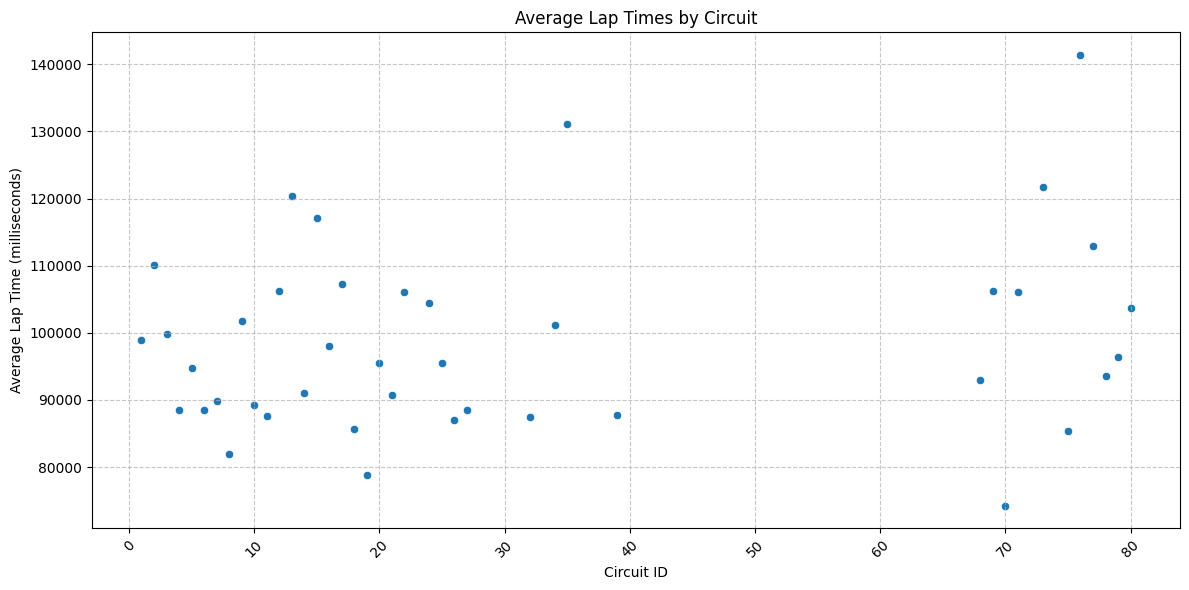

In [5]:
# Create the scatter plot
plt.figure(figsize=(12, 6))
sns.scatterplot(x='circuitId', y='avg_lap', data=df_eachCirc)
plt.title('Average Lap Times by Circuit')
plt.xlabel('Circuit ID')
plt.ylabel('Average Lap Time (milliseconds)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

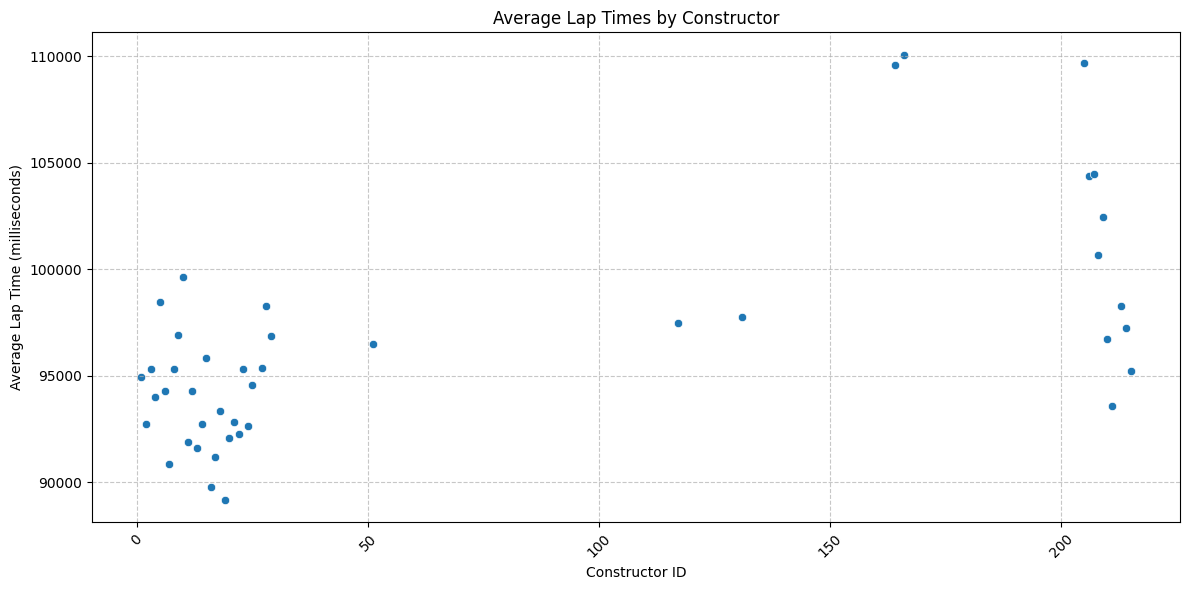

In [6]:
# Create the scatter plot
plt.figure(figsize=(12, 6))
sns.scatterplot(x='constructorId', y='avg_lap', data=df_eachConst)
plt.title('Average Lap Times by Constructor')
plt.xlabel('Constructor ID')
plt.ylabel('Average Lap Time (milliseconds)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

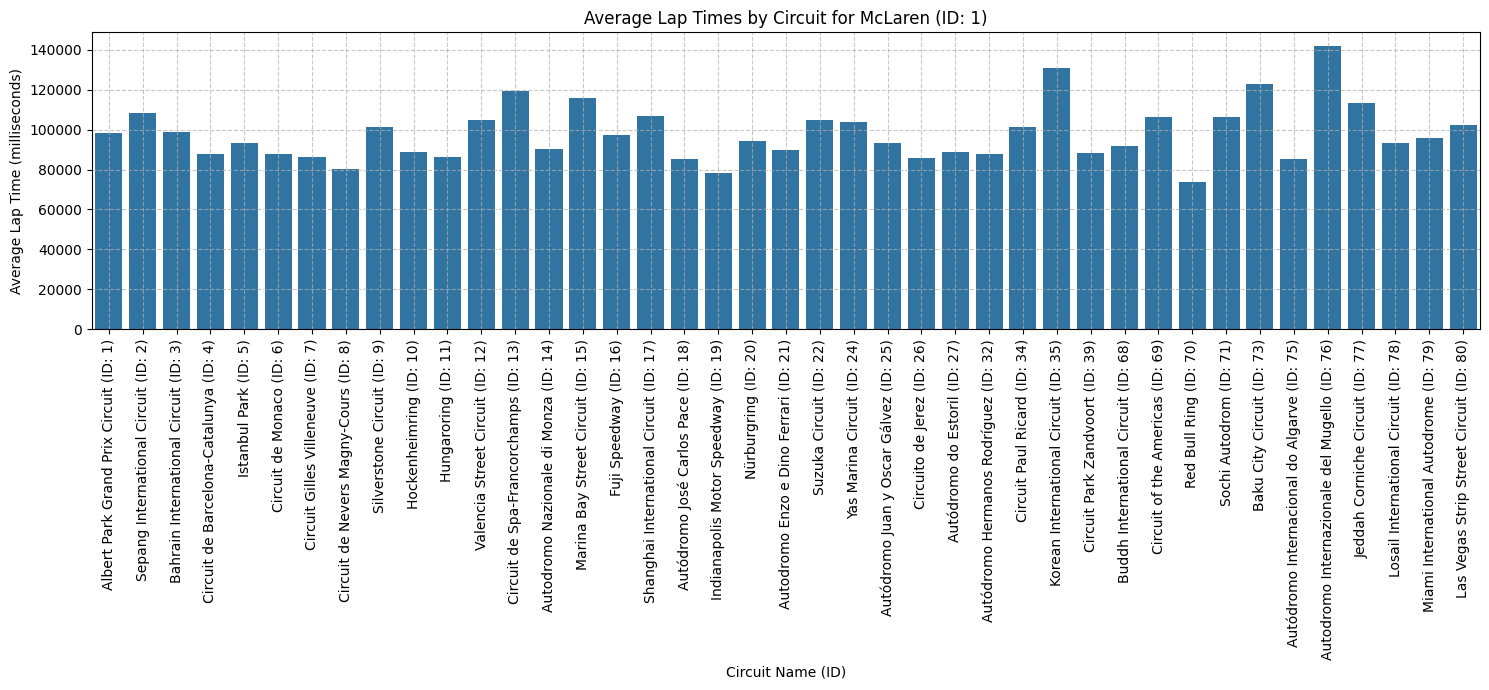

In [30]:
df_filtered = df[df['constructorId'] == 1]

# Get constructor name and ID
constructor_id = 1
constructor_name = constructor_data[constructor_data['constructorId'] == constructor_id]['name'].iloc[0]

# Merge with circuit data to get circuit names
df_filtered_with_names = pd.merge(df_filtered, circuit_data[['circuitId', 'name']], on='circuitId', how='left')
df_filtered_with_names['circuit_display_name'] = df_filtered_with_names['name_y'] + ' (ID: ' + df_filtered_with_names['circuitId'].astype(str) + ')'

# Create the bar plot
plt.figure(figsize=(15, 7))
sns.barplot(x='circuit_display_name', y='avg_lap', data=df_filtered_with_names)
plt.title(f'Average Lap Times by Circuit for {constructor_name} (ID: {constructor_id})')
plt.xlabel('Circuit Name (ID)')
plt.ylabel('Average Lap Time (milliseconds)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=90) # Rotate labels for better readability
plt.tight_layout()
plt.show()

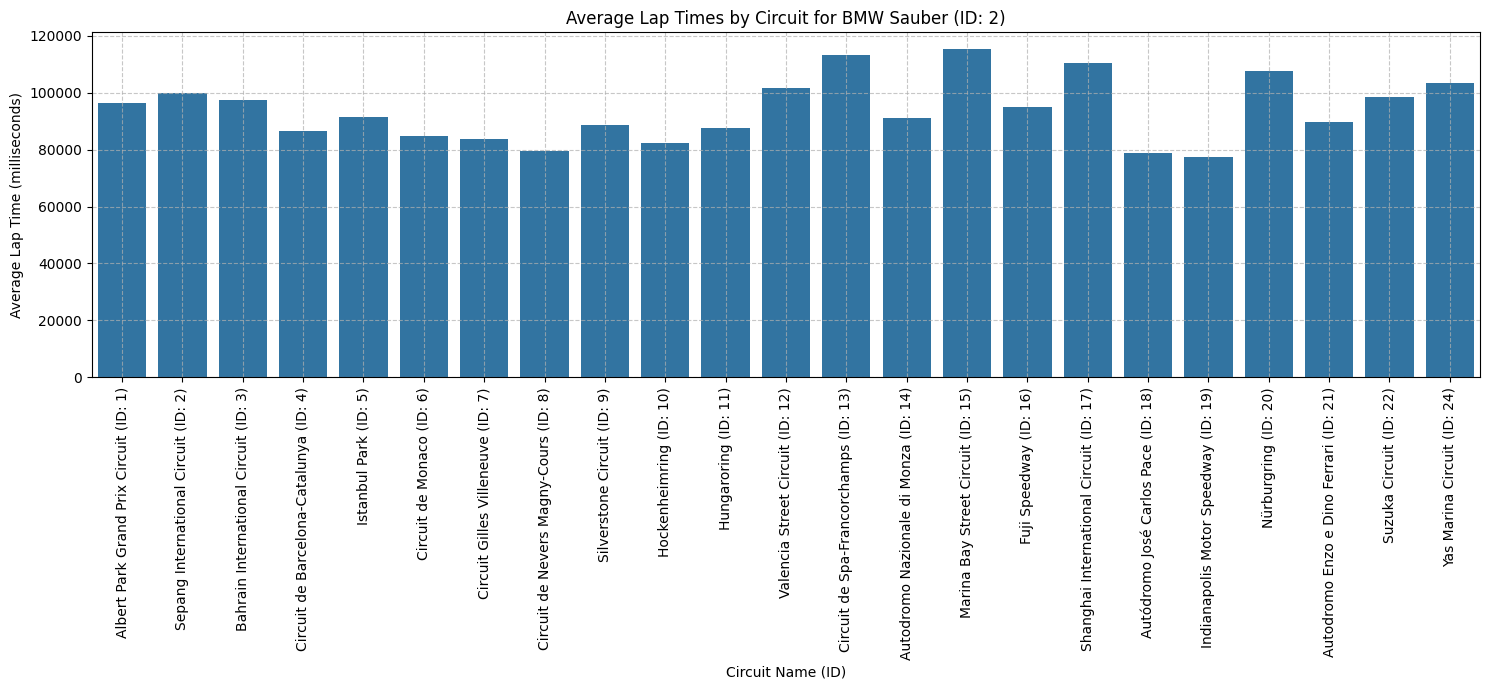

In [26]:
df_filtered = df[df['constructorId'] == 2]

# Get constructor name and ID
constructor_id = 2
constructor_name = constructor_data[constructor_data['constructorId'] == constructor_id]['name'].iloc[0]

# Merge with circuit data to get circuit names
df_filtered_with_names = pd.merge(df_filtered, circuit_data[['circuitId', 'name']], on='circuitId', how='left')
df_filtered_with_names['circuit_display_name'] = df_filtered_with_names['name_y'] + ' (ID: ' + df_filtered_with_names['circuitId'].astype(str) + ')'

# Create the bar plot
plt.figure(figsize=(15, 7))
sns.barplot(x='circuit_display_name', y='avg_lap', data=df_filtered_with_names)
plt.title(f'Average Lap Times by Circuit for {constructor_name} (ID: {constructor_id})')
plt.xlabel('Circuit Name (ID)')
plt.ylabel('Average Lap Time (milliseconds)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=90) # Rotate labels for better readability
plt.tight_layout()
plt.show()

In [31]:
# Find the minimum laptime average and the corresponding circuit id for each contructor
min_lap_per_constructor = df.loc[df.groupby('constructorId')['avg_lap'].idxmin()]
print("Constructor with their minimum average lap time, and the circuit where it occurred:")
print(min_lap_per_constructor.head())

Constructor with their minimum average lap time, and the circuit where it occurred:
     circuitId  constructorId        name     avg_lap
32          70              1     McLaren  73823.2483
59          19              2  BMW Sauber  77225.2583
96          70              3    Williams  74588.1943
133         70              4     Renault  74088.4759
166         70              5  Toro Rosso  73828.2779


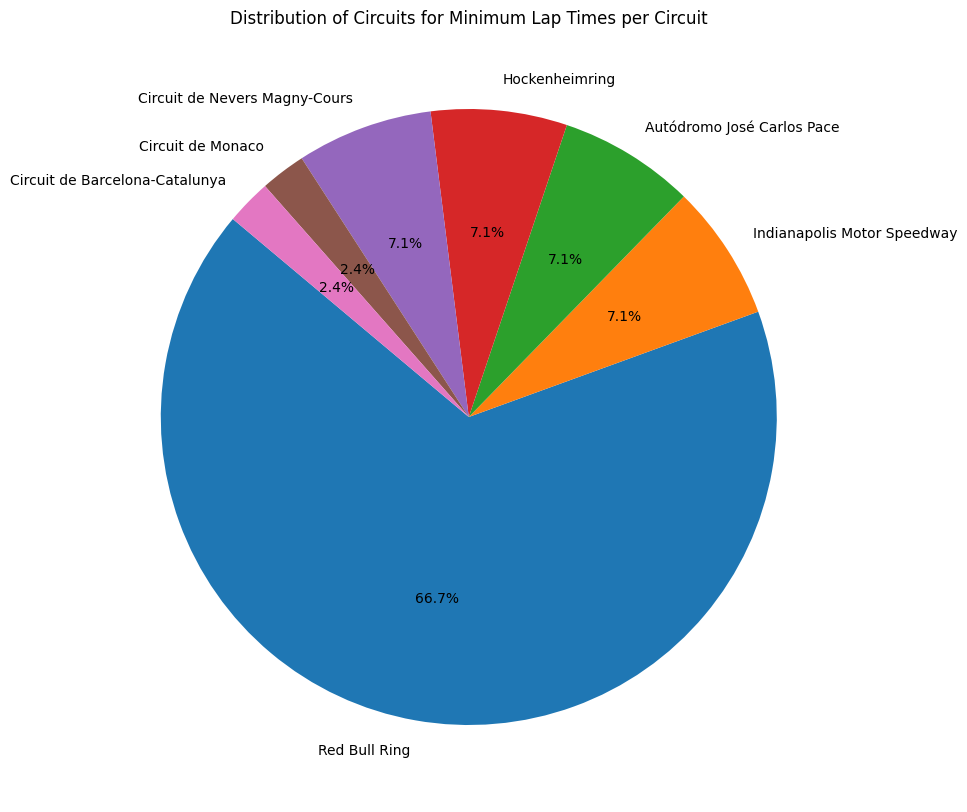

In [32]:
# Get the circuit name
cir_names_df = pd.read_csv('/content/drive/MyDrive/UBCO/COSC301/Lab9/circuits.csv')
merged_min_laps = pd.merge(min_lap_per_constructor, cir_names_df[['circuitId', 'name']], on='circuitId', how='left')

# Count the occurance of each circuit
circuit_name_counts_min = merged_min_laps['name_y'].value_counts()

# Create a pie chart
plt.figure(figsize=(10, 10))
plt.pie(circuit_name_counts_min, labels=circuit_name_counts_min.index, autopct='%1.1f%%', startangle=140)
plt.title('Distribution of Circuits for Minimum Lap Times per Circuit')
plt.ylabel('')
plt.show()

In [11]:
# Find the minimum laptime average and the corresponding circuit id for each contructor
max_lap_per_constructor = df.loc[df.groupby('constructorId')['avg_lap'].idxmax()]
print("Constructor with their maximum average lap time, and the circuit where it occurred:")
print(max_lap_per_constructor.head())

Constructor with their maximum average lap time, and the circuit where it occurred:
     circuitId  constructorId        name      avg_lap
36          76              1     McLaren  141771.8281
55          15              2  BMW Sauber  115415.7624
100         76              3    Williams  141791.3077
130         35              4     Renault  159461.3354
163         35              5  Toro Rosso  129217.3683


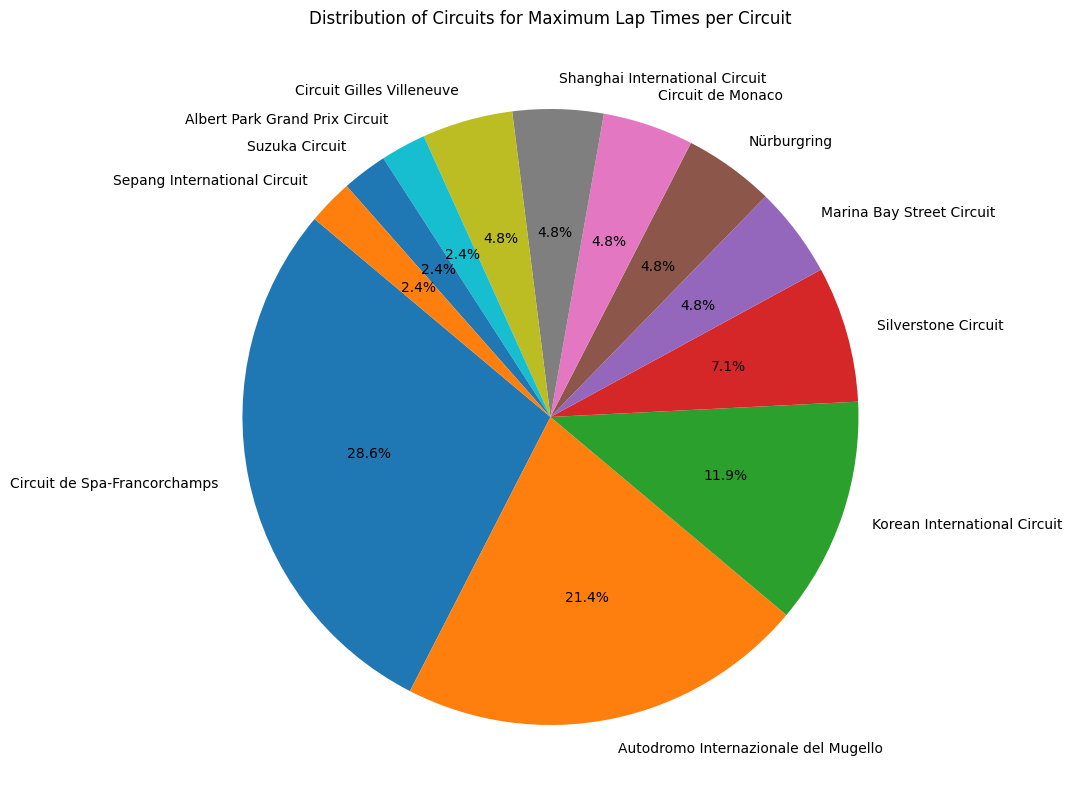

In [33]:
# Get the circuit name
merged_max_laps = pd.merge(max_lap_per_constructor, cir_names_df[['circuitId', 'name']], on='circuitId', how='left')

# Count the occurance of each circuit
circuit_name_counts_max = merged_max_laps['name_y'].value_counts()

# Create a pie chart
plt.figure(figsize=(10, 10))
plt.pie(circuit_name_counts_max, labels=circuit_name_counts_max.index, autopct='%1.1f%%', startangle=140)
plt.title('Distribution of Circuits for Maximum Lap Times per Circuit')
plt.ylabel('')
plt.show()

In [34]:
min_df = min_lap_per_constructor[['constructorId', 'circuitId', 'avg_lap']].rename(columns={'circuitId': 'min_circuitId', 'avg_lap': 'min_avg_milliseconds'})
max_df = max_lap_per_constructor[['constructorId', 'circuitId', 'avg_lap']].rename(columns={'circuitId': 'max_circuitId', 'avg_lap': 'max_avg_milliseconds'})

merged_df = pd.merge(min_df, max_df, on='constructorId', how='inner')

merged_df['difference_avg_milliseconds'] = merged_df['max_avg_milliseconds'] - merged_df['min_avg_milliseconds']

result_df = merged_df[['constructorId', 'min_circuitId', 'min_avg_milliseconds', 'max_circuitId', 'max_avg_milliseconds', 'difference_avg_milliseconds']]
sorted_df = result_df.sort_values(by='difference_avg_milliseconds', ascending=False)

print("Constructor Performance Summary (Min, Max, and Difference in Average Lap Times):") #Difference in Average Lap Times = max lap time - min lap time
display(sorted_df.head())

Constructor Performance Summary (Min, Max, and Difference in Average Lap Times):


,constructorId,min_circuitId,min_avg_milliseconds,max_circuitId,max_avg_milliseconds,difference_avg_milliseconds
11,12,19,77702.6028,20,223770.8000,146068.1972
33,205,18,81546.9783,7,167952.5990,86405.6207
3,4,70,74088.4759,35,159461.3354,85372.8595
32,166,10,83684.9561,35,158219.7439,74534.7878
30,131,70,72270.2923,76,141991.5254,69721.2331


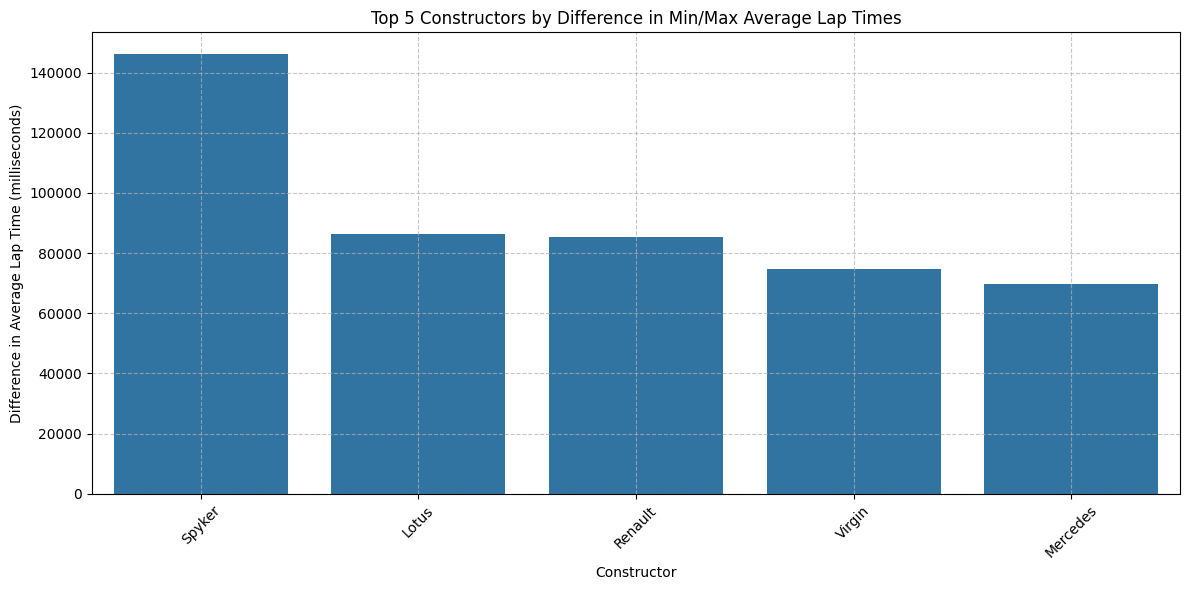

In [36]:
# Get top five from the table above
top5_constructors_df = sorted_df.head(5)
top5_names_df=pd.merge(top5_constructors_df, constructor_data, on='constructorId', how='inner')

# Create a bar plot
plt.figure(figsize=(12, 6))
sns.barplot(x='name', y='difference_avg_milliseconds', data=top5_names_df)
plt.title('Top 5 Constructors by Difference in Min/Max Average Lap Times')
plt.xlabel('Constructor')
plt.ylabel('Difference in Average Lap Time (milliseconds)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

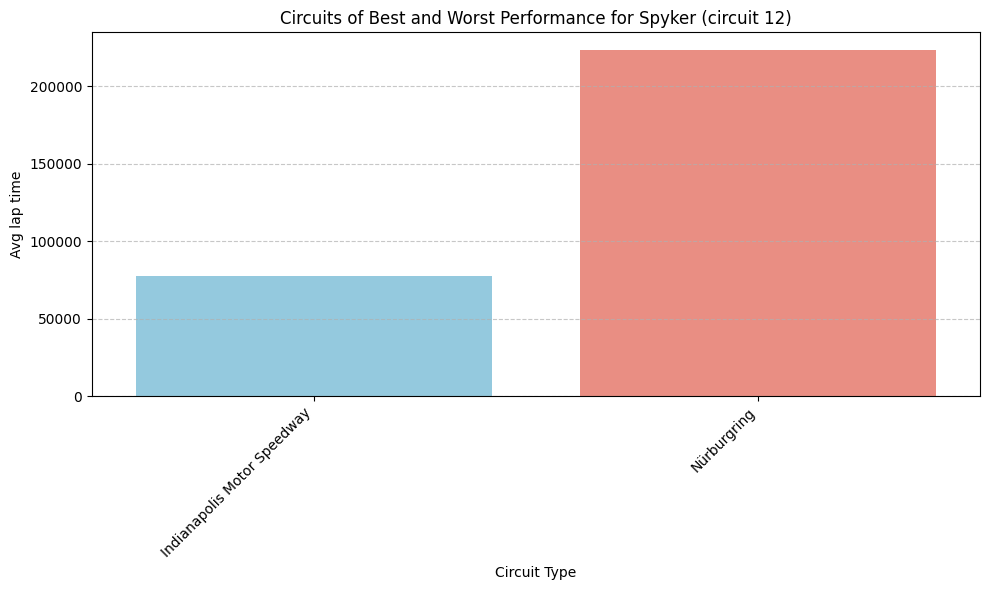

In [15]:
filtered = sorted_df[sorted_df['constructorId'] == 12]

if not constructor_data.empty:
    min_avg_milliseconds = filtered['min_avg_milliseconds'].iloc[0]
    max_avg_milliseconds = filtered['max_avg_milliseconds'].iloc[0]

    min_circuit_id_val = filtered['min_circuitId'].iloc[0]
    max_circuit_id_val = filtered['max_circuitId'].iloc[0]

    min_circuit_name = cir_names_df[circuit_data['circuitId'] == min_circuit_id_val]['name'].iloc[0]
    max_circuit_name = cir_names_df[circuit_data['circuitId'] == max_circuit_id_val]['name'].iloc[0]

    circuits_to_plot = pd.DataFrame({
        'Circuit Type': [min_circuit_name, max_circuit_name],
        'Avg lap time': [min_avg_milliseconds, max_avg_milliseconds],
        'Performance': ['Min Lap Time', 'Max Lap Time'] # For hue to distinguish
    })

    plt.figure(figsize=(10, 6))
    sns.barplot(x='Circuit Type', y='Avg lap time', data=circuits_to_plot, hue='Performance', palette=['skyblue', 'salmon'], legend=False)
    plt.title('Circuits of Best and Worst Performance for Spyker (circuit 12)')
    plt.ylabel('Avg lap time')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.xticks(rotation=45, ha='right') # Rotate labels for better readability if names are long
    plt.tight_layout()
    plt.show()
else:
    print("Constructor 4 data not found in the summary.")

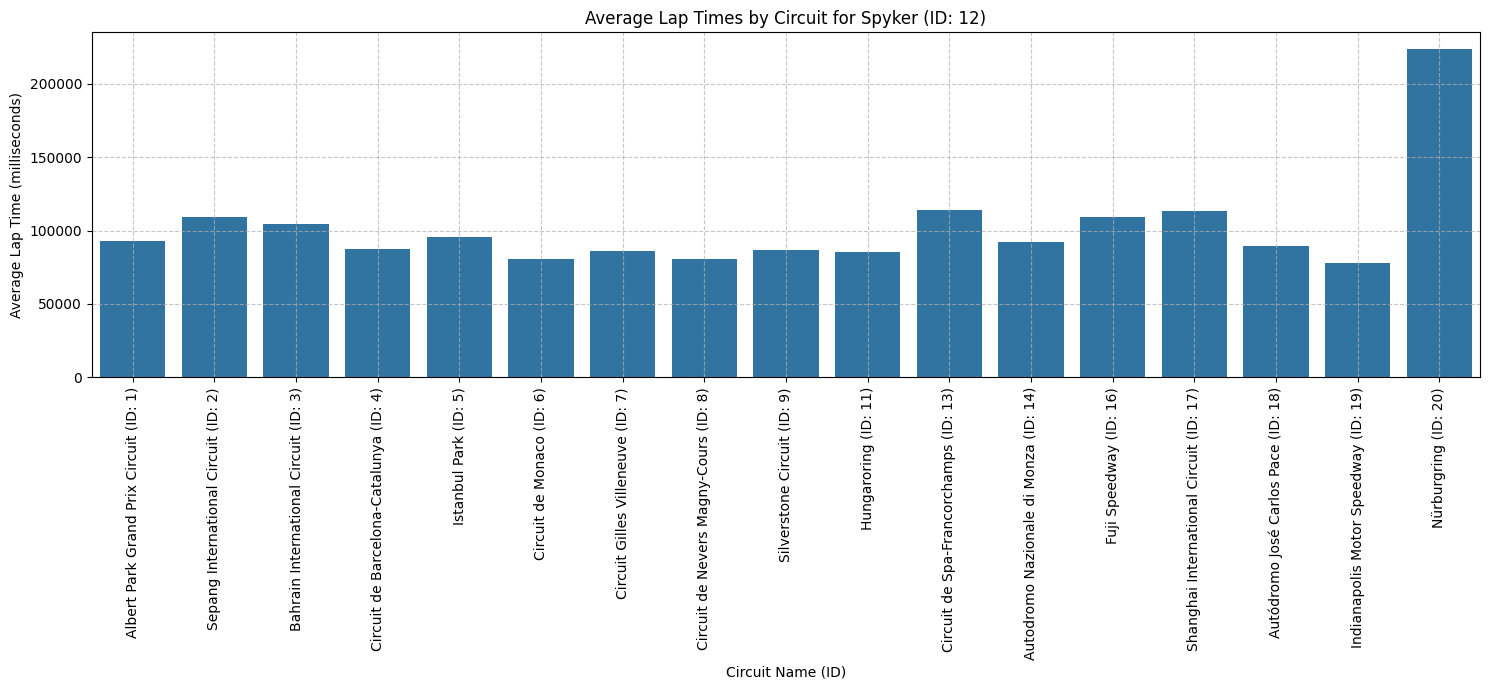

In [24]:
df_filtered = df[df['constructorId'] == 12]

# Get constructor name and ID
constructor_id = 12
constructor_name = constructor_data[constructor_data['constructorId'] == constructor_id]['name'].iloc[0]

# Merge with circuit data to get circuit names
df_filtered_with_names = pd.merge(df_filtered, cir_names_df[['circuitId', 'name']], on='circuitId', how='left')
df_filtered_with_names['circuit_display_name'] = df_filtered_with_names['name_y'] + ' (ID: ' + df_filtered_with_names['circuitId'].astype(str) + ')'

# Create the bar plot
plt.figure(figsize=(15, 7))
sns.barplot(x='circuit_display_name', y='avg_lap', data=df_filtered_with_names)
plt.title(f'Average Lap Times by Circuit for {constructor_name} (ID: {constructor_id})')
plt.xlabel('Circuit Name (ID)')
plt.ylabel('Average Lap Time (milliseconds)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=90) # Rotate labels for better readability
plt.tight_layout()
plt.show()

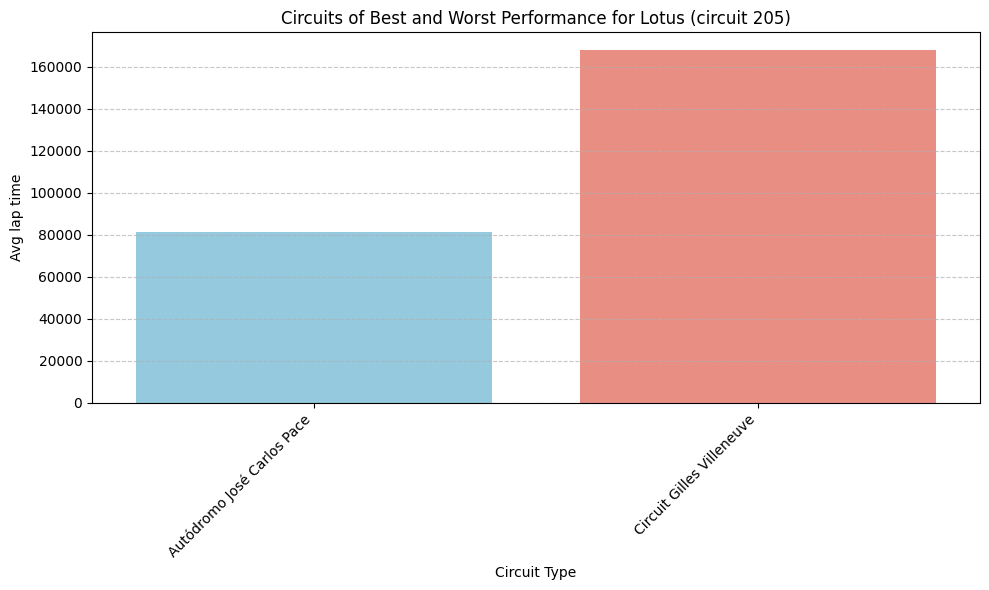

In [18]:
filtered = sorted_df[sorted_df['constructorId'] == 205]

if not constructor_data.empty:
    min_avg_milliseconds = filtered['min_avg_milliseconds'].iloc[0]
    max_avg_milliseconds = filtered['max_avg_milliseconds'].iloc[0]

    min_circuit_id_val = filtered['min_circuitId'].iloc[0]
    max_circuit_id_val = filtered['max_circuitId'].iloc[0]

    min_circuit_name = cir_names_df[circuit_data['circuitId'] == min_circuit_id_val]['name'].iloc[0]
    max_circuit_name = cir_names_df[circuit_data['circuitId'] == max_circuit_id_val]['name'].iloc[0]

    circuits_to_plot = pd.DataFrame({
        'Circuit Type': [min_circuit_name, max_circuit_name],
        'Avg lap time': [min_avg_milliseconds, max_avg_milliseconds],
        'Performance': ['Min Lap Time', 'Max Lap Time'] # For hue to distinguish
    })

    plt.figure(figsize=(10, 6))
    sns.barplot(x='Circuit Type', y='Avg lap time', data=circuits_to_plot, hue='Performance', palette=['skyblue', 'salmon'], legend=False)
    plt.title('Circuits of Best and Worst Performance for Lotus (circuit 205)')
    plt.ylabel('Avg lap time')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.xticks(rotation=45, ha='right') # Rotate labels for better readability if names are long
    plt.tight_layout()
    plt.show()
else:
    print("Constructor 4 data not found in the summary.")

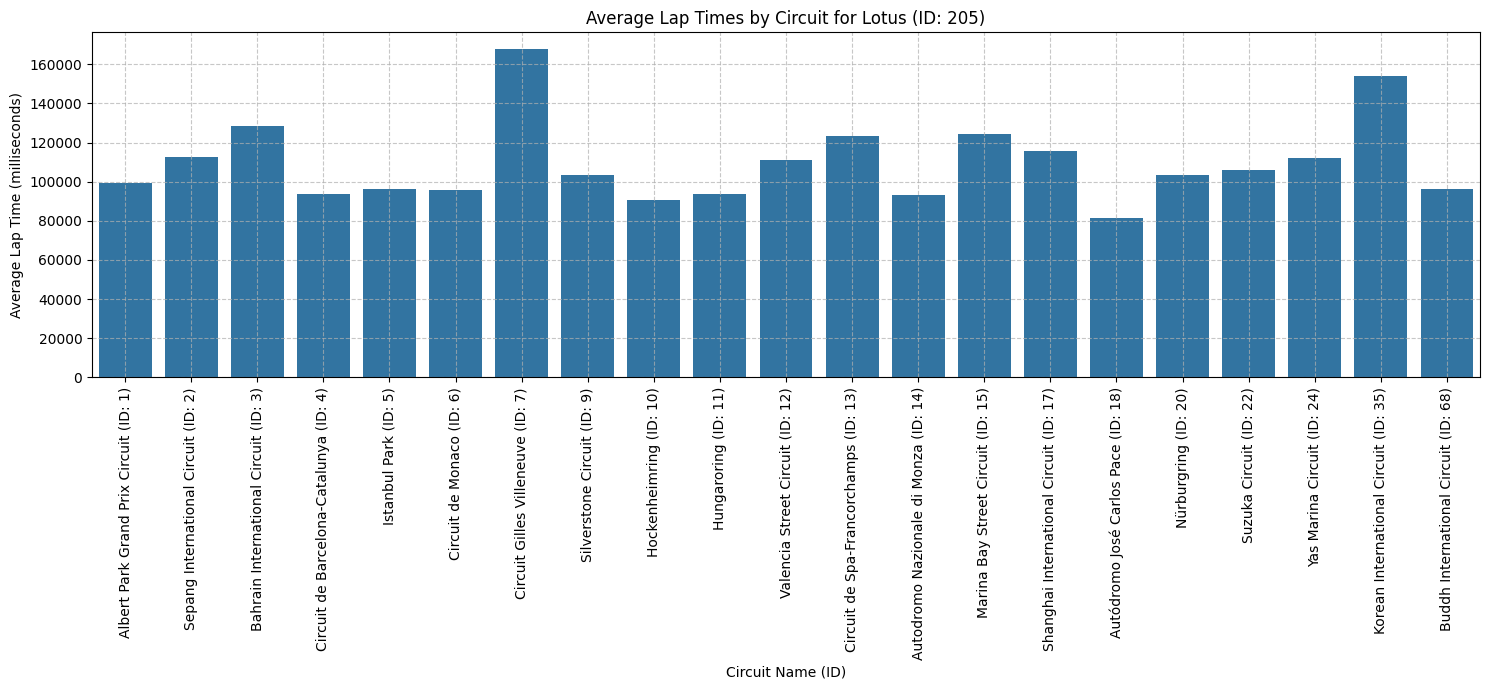

In [22]:
df_filtered = df[df['constructorId'] == 205]

# Get constructor name and ID
constructor_id = 205
constructor_name = constructor_data[constructor_data['constructorId'] == constructor_id]['name'].iloc[0]

# Merge with circuit data to get circuit names
df_filtered_with_names = pd.merge(df_filtered, cir_names_df[['circuitId', 'name']], on='circuitId', how='left')
df_filtered_with_names['circuit_display_name'] = df_filtered_with_names['name_y'] + ' (ID: ' + df_filtered_with_names['circuitId'].astype(str) + ')'

# Create the bar plot
plt.figure(figsize=(15, 7))
sns.barplot(x='circuit_display_name', y='avg_lap', data=df_filtered_with_names)
plt.title(f'Average Lap Times by Circuit for {constructor_name} (ID: {constructor_id})')
plt.xlabel('Circuit Name (ID)')
plt.ylabel('Average Lap Time (milliseconds)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=90) # Rotate labels for better readability
plt.tight_layout()
plt.show()

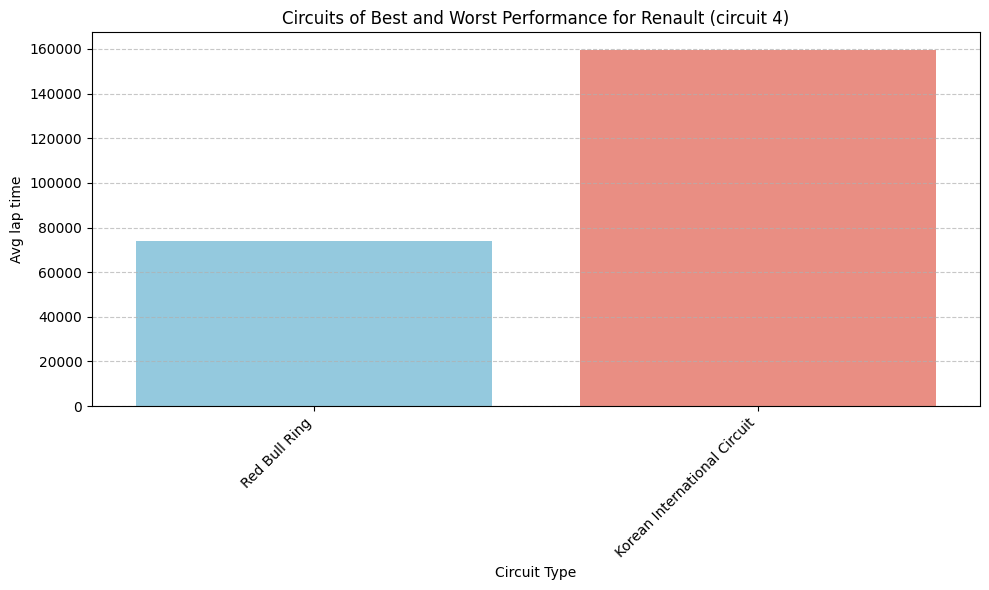

In [ ]:
filtered = sorted_df[sorted_df['constructorId'] == 4]

if not constructor_data.empty:
    min_avg_milliseconds = filtered['min_avg_milliseconds'].iloc[0]
    max_avg_milliseconds = filtered['max_avg_milliseconds'].iloc[0]

    min_circuit_id_val = filtered['min_circuitId'].iloc[0]
    max_circuit_id_val = filtered['max_circuitId'].iloc[0]

    min_circuit_name = cir_names_df[circuit_data['circuitId'] == min_circuit_id_val]['name'].iloc[0]
    max_circuit_name = cir_names_df[circuit_data['circuitId'] == max_circuit_id_val]['name'].iloc[0]

    circuits_to_plot = pd.DataFrame({
        'Circuit Type': [min_circuit_name, max_circuit_name],
        'Avg lap time': [min_avg_milliseconds, max_avg_milliseconds],
        'Performance': ['Min Lap Time', 'Max Lap Time'] # For hue to distinguish
    })


    plt.figure(figsize=(10, 6))
    sns.barplot(x='Circuit Type', y='Avg lap time', data=circuits_to_plot, hue='Performance', palette=['skyblue', 'salmon'], legend=False)
    plt.title('Circuits of Best and Worst Performance for Renault (circuit 4)')
    plt.ylabel('Avg lap time')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.xticks(rotation=45, ha='right') # Rotate labels for better readability if names are long
    plt.tight_layout()
    plt.show()
else:
    print("Constructor 4 data not found in the summary.")

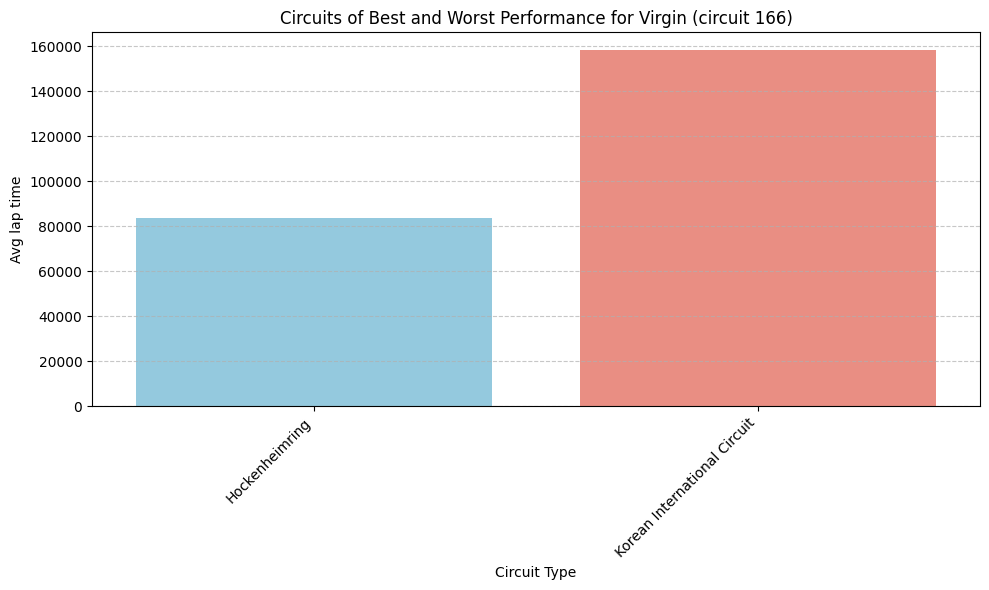

In [ ]:
filtered = sorted_df[sorted_df['constructorId'] == 166]

if not constructor_data.empty:
    min_avg_milliseconds =filtered['min_avg_milliseconds'].iloc[0]
    max_avg_milliseconds = filtered['max_avg_milliseconds'].iloc[0]

    min_circuit_id_val = filtered['min_circuitId'].iloc[0]
    max_circuit_id_val = filtered['max_circuitId'].iloc[0]

    min_circuit_name = cir_names_df[circuit_data['circuitId'] == min_circuit_id_val]['name'].iloc[0]
    max_circuit_name = cir_names_df[circuit_data['circuitId'] == max_circuit_id_val]['name'].iloc[0]

    circuits_to_plot = pd.DataFrame({
        'Circuit Type': [min_circuit_name, max_circuit_name],
        'Avg lap time': [min_avg_milliseconds, max_avg_milliseconds],
        'Performance': ['Min Lap Time', 'Max Lap Time'] # For hue to distinguish
    })

    plt.figure(figsize=(10, 6))
    sns.barplot(x='Circuit Type', y='Avg lap time', data=circuits_to_plot, hue='Performance', palette=['skyblue', 'salmon'], legend=False)
    plt.title('Circuits of Best and Worst Performance for Virgin (circuit 166)')
    plt.ylabel('Avg lap time')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.xticks(rotation=45, ha='right') # Rotate labels for better readability if names are long
    plt.tight_layout()
    plt.show()
else:
    print("Constructor 4 data not found in the summary.")

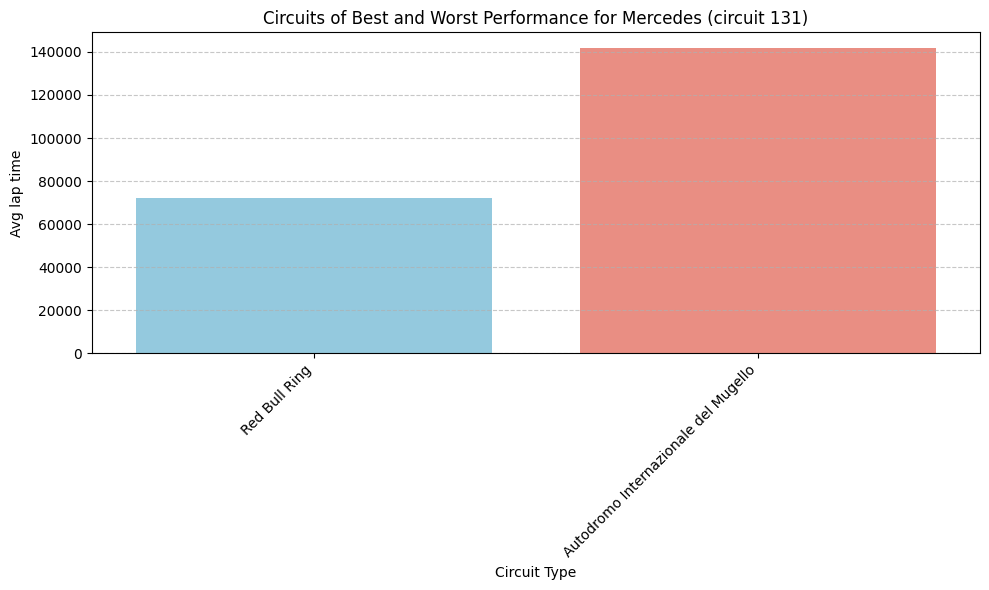

In [ ]:
filtered = sorted_df[sorted_df['constructorId'] == 131]

if not constructor_data.empty:
    min_avg_milliseconds = filtered['min_avg_milliseconds'].iloc[0]
    max_avg_milliseconds =filtered['max_avg_milliseconds'].iloc[0]

    min_circuit_id_val = filtered['min_circuitId'].iloc[0]
    max_circuit_id_val = filtered['max_circuitId'].iloc[0]

    min_circuit_name = cir_names_df[circuit_data['circuitId'] == min_circuit_id_val]['name'].iloc[0]
    max_circuit_name = cir_names_df[circuit_data['circuitId'] == max_circuit_id_val]['name'].iloc[0]

    circuits_to_plot = pd.DataFrame({
        'Circuit Type': [min_circuit_name, max_circuit_name],
        'Avg lap time': [min_avg_milliseconds, max_avg_milliseconds],
        'Performance': ['Min Lap Time', 'Max Lap Time'] # For hue to distinguish
    })

    plt.figure(figsize=(10, 6))
    sns.barplot(x='Circuit Type', y='Avg lap time', data=circuits_to_plot, hue='Performance', palette=['skyblue', 'salmon'], legend=False)
    plt.title('Circuits of Best and Worst Performance for Mercedes (circuit 131)')
    plt.ylabel('Avg lap time')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.xticks(rotation=45, ha='right') # Rotate labels for better readability if names are long
    plt.tight_layout()
    plt.show()
else:
    print("Constructor 4 data not found in the summary.")